In [24]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.rcParams["figure.figsize"]=(10,5)
rd = Path.cwd().parent/'data'/'raw'
wd = Path.cwd().parent/'reports'


In [25]:
fund = pd.read_csv(rd/"01_fund_master.csv")

nav = pd.read_csv(rd/"02_nav_history.csv")

aum = pd.read_csv(rd/"03_aum_by_fund_house.csv")

sip = pd.read_csv(rd/"04_monthly_sip_inflows.csv")

category = pd.read_csv(rd/"05_category_inflows.csv")

folio = pd.read_csv(rd/"06_industry_folio_count.csv")

perf = pd.read_csv(rd/"07_scheme_performance.csv")

txn = pd.read_csv(rd/"08_investor_transactions.csv")

portfolio = pd.read_csv(rd/"09_portfolio_holdings.csv")

In [26]:
print("Fund :",fund.shape)
print("NAV :",nav.shape)
print("AUM :",aum.shape)
print("SIP :",sip.shape)
print("Category :",category.shape)
print("Folio :",folio.shape)
print("Performance :",perf.shape)
print("Transactions :",txn.shape)
print("Portfolio :",portfolio.shape)

Fund : (40, 15)
NAV : (46000, 3)
AUM : (90, 5)
SIP : (48, 6)
Category : (144, 3)
Folio : (21, 6)
Performance : (40, 19)
Transactions : (32778, 13)
Portfolio : (322, 8)


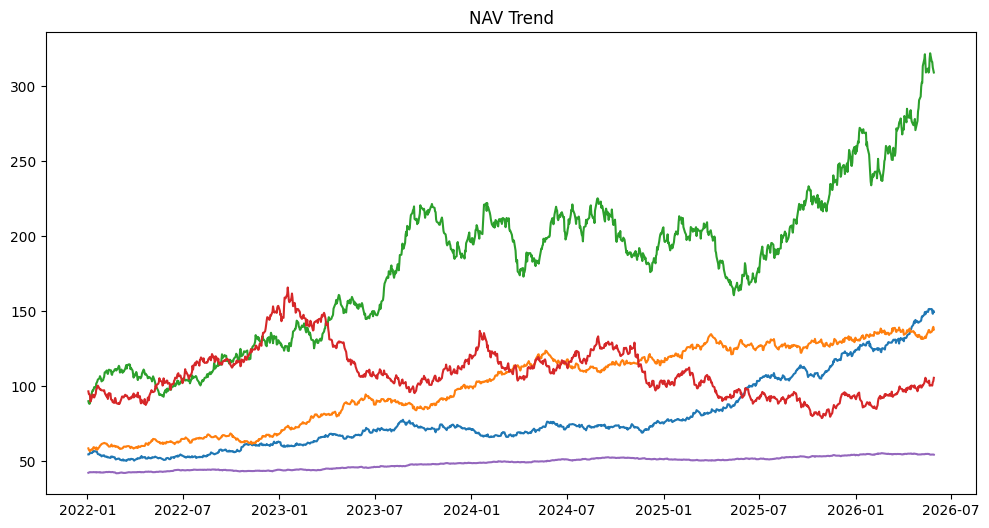

In [27]:
nav["date"]=pd.to_datetime(nav["date"])

sample_funds = nav["amfi_code"].unique()[:5]

plt.figure(figsize=(12,6))

for fund_code in sample_funds:
    
    temp = nav[
        nav["amfi_code"]==fund_code
    ]
    
    plt.plot(
        temp["date"],
        temp["nav"]
    )

plt.title("NAV Trend")
plt.show()

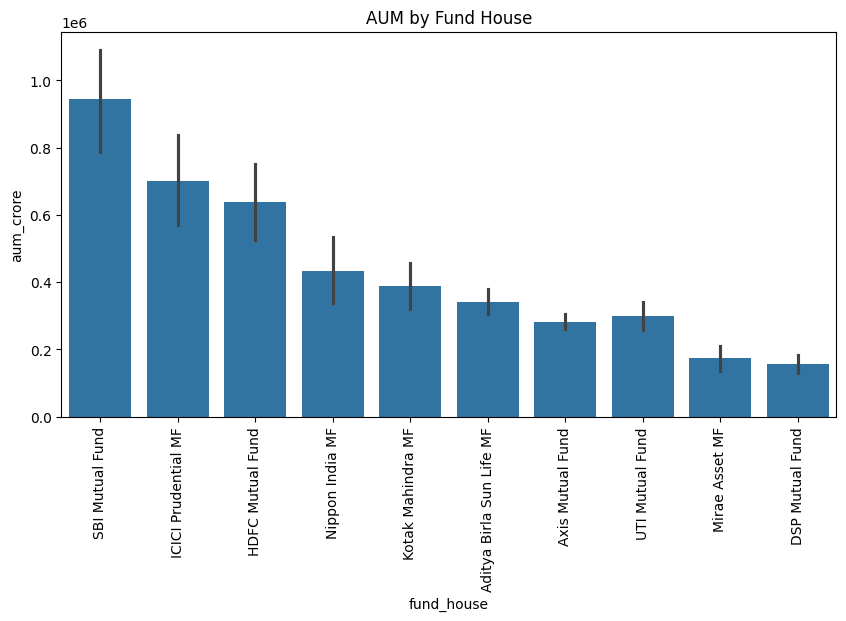

In [28]:
sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_crore"
)

plt.xticks(rotation=90)

plt.title("AUM by Fund House")

plt.show()

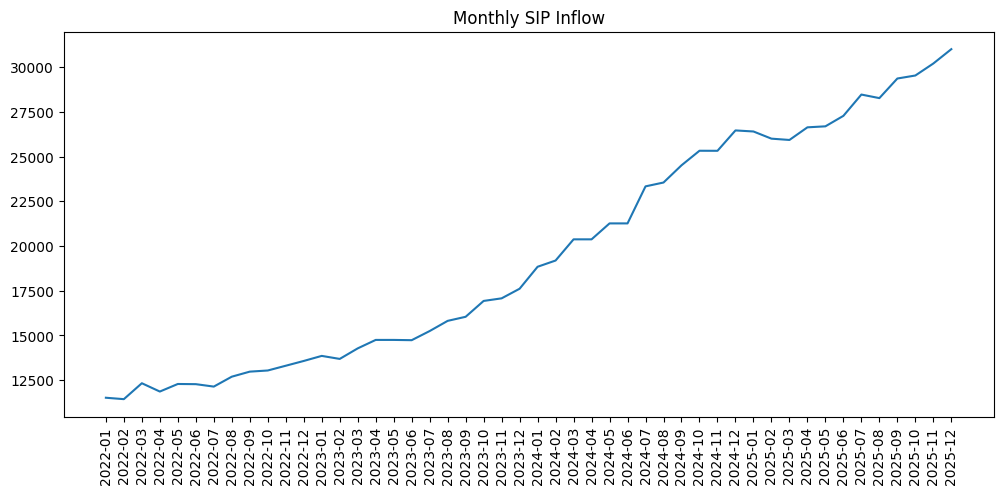

In [29]:
plt.figure(figsize=(12,5))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"]
)

plt.xticks(rotation=90)

plt.title("Monthly SIP Inflow")

plt.show()

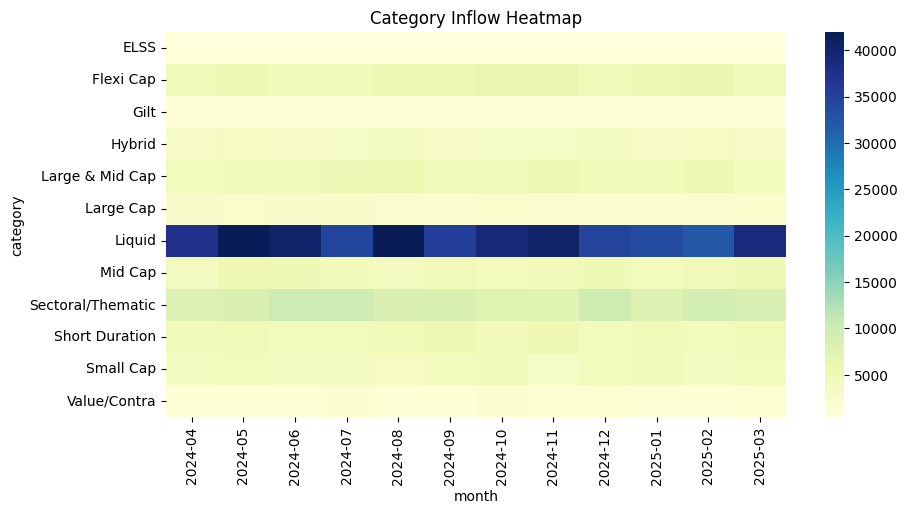

In [30]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")

plt.show()

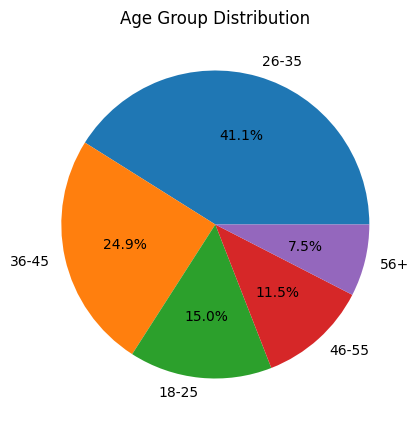

In [31]:
txn["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Age Group Distribution")

plt.show()

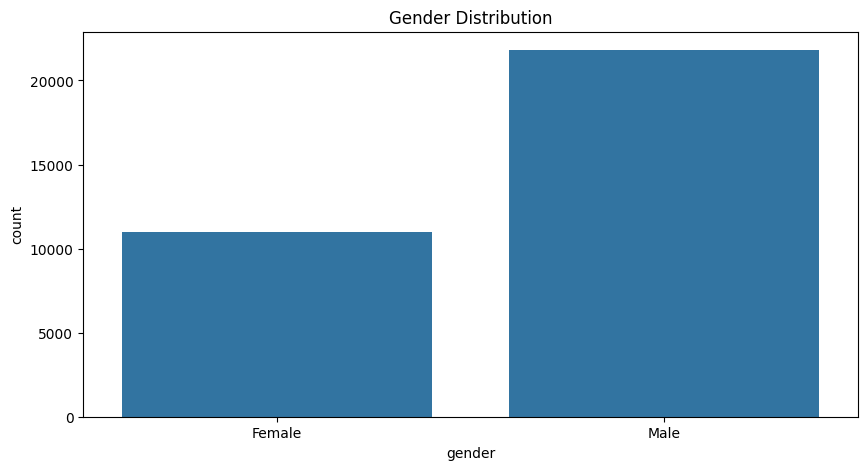

In [32]:
sns.countplot(
    data=txn,
    x="gender"
)

plt.title("Gender Distribution")

plt.show()

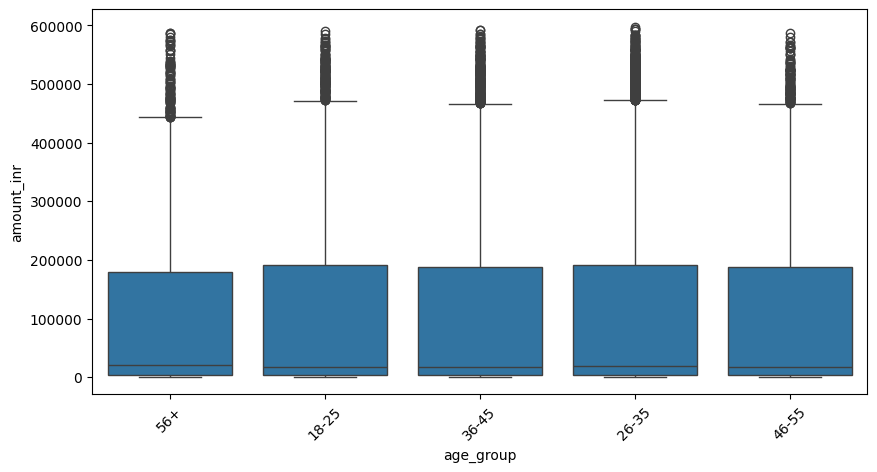

In [33]:
sns.boxplot(
    data=txn,
    x="age_group",
    y="amount_inr"
)

plt.xticks(rotation=45)

plt.show()

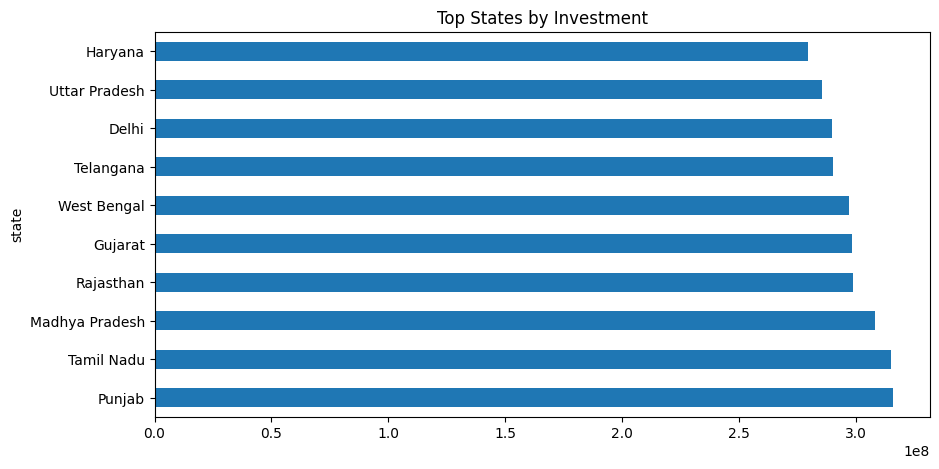

In [34]:
state_amt = txn.groupby(
    "state"
)["amount_inr"].sum().sort_values(
    ascending=False
).head(10)

state_amt.plot(
    kind="barh"
)

plt.title("Top States by Investment")

plt.show()

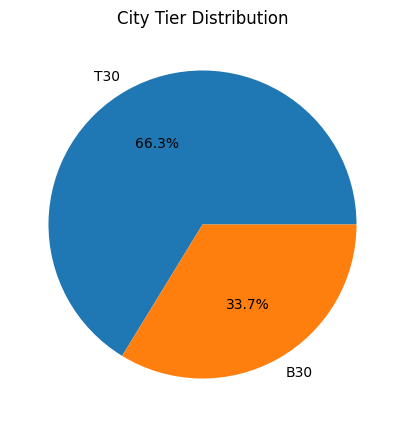

In [35]:
txn["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("City Tier Distribution")

plt.show()

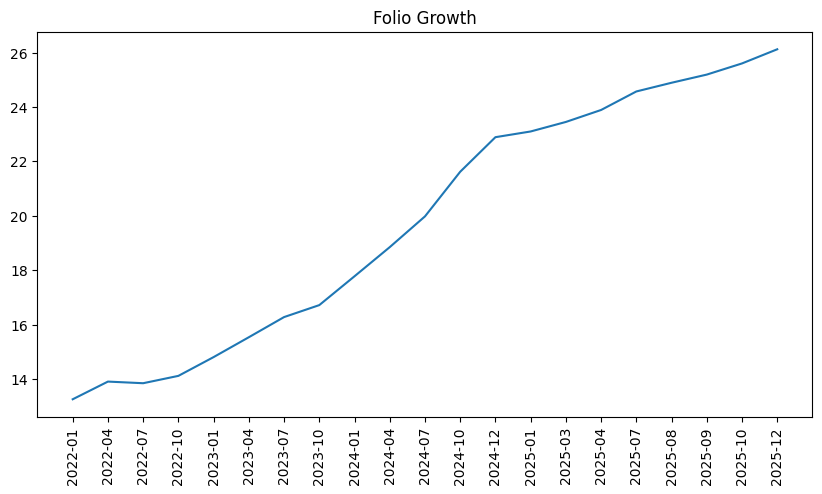

In [36]:
plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.xticks(rotation=90)

plt.title("Folio Growth")

plt.show()

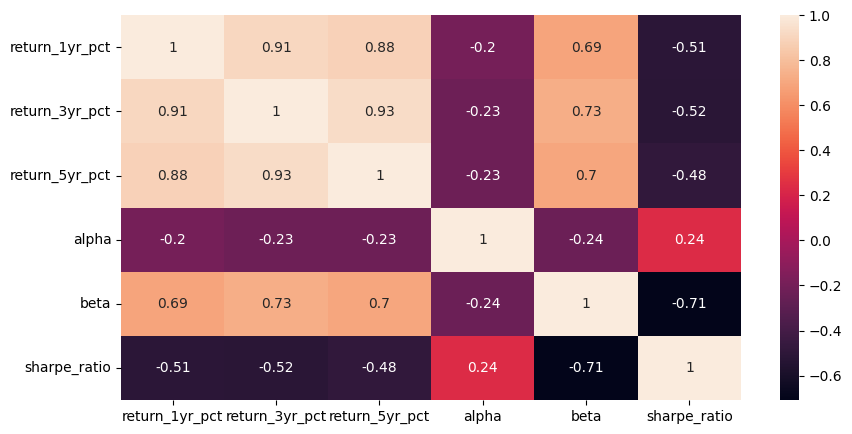

In [37]:
corr = perf[
[
"return_1yr_pct",
"return_3yr_pct",
"return_5yr_pct",
"alpha",
"beta",
"sharpe_ratio"
]
].corr()

sns.heatmap(
    corr,
    annot=True
)

plt.show()

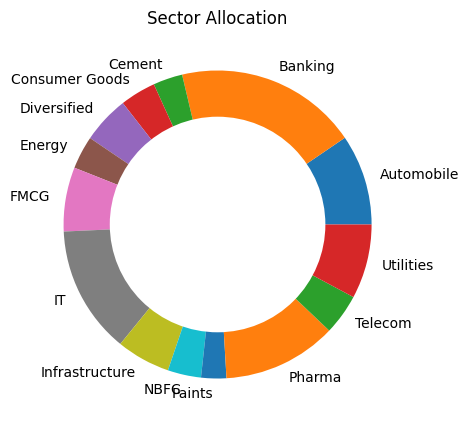

In [38]:
sector = portfolio.groupby(
    "sector"
)["weight_pct"].sum()

plt.pie(
    sector,
    labels=sector.index
)

centre = plt.Circle(
    (0,0),
    0.70,
    fc='white'
)

fig = plt.gcf()

fig.gca().add_artist(
    centre
)

plt.title("Sector Allocation")

plt.show()

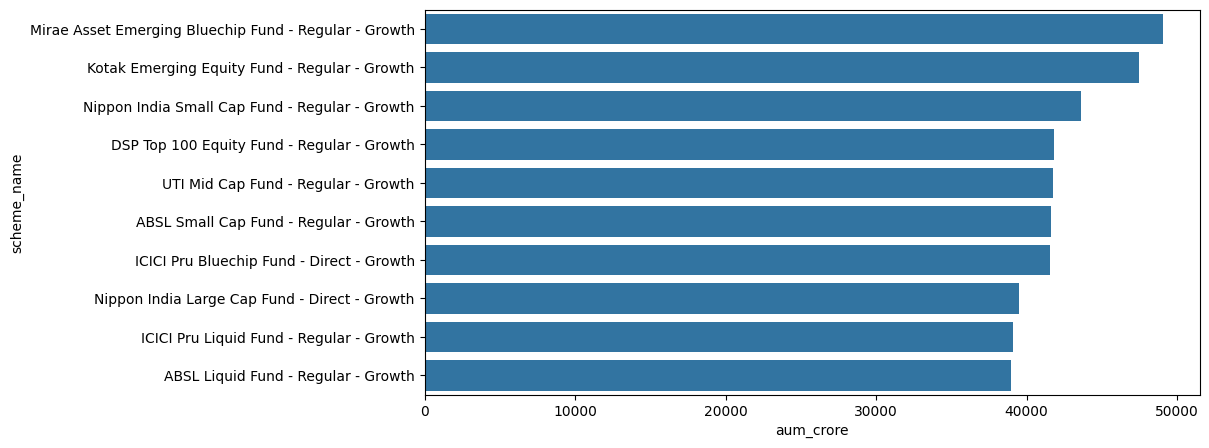

In [39]:
top10 = perf.nlargest(
    10,
    "aum_crore"
)

sns.barplot(
    data=top10,
    x="aum_crore",
    y="scheme_name"
)

plt.show()

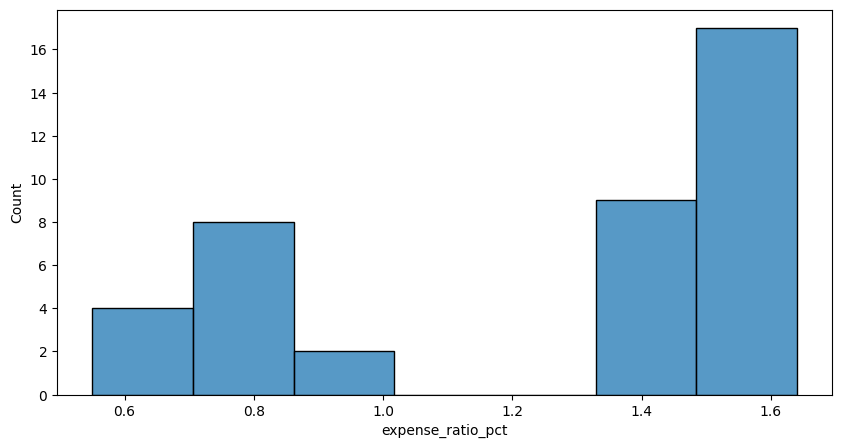

In [40]:
sns.histplot(
    perf["expense_ratio_pct"]
)

plt.show()

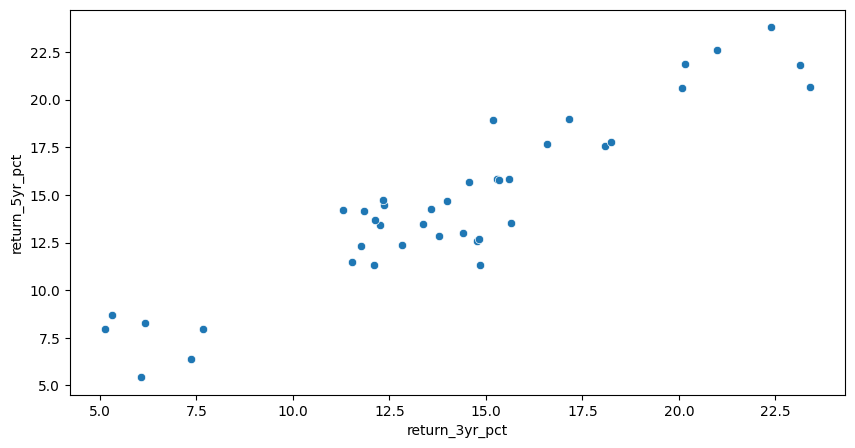

In [41]:
sns.scatterplot(
    data=perf,
    x="return_3yr_pct",
    y="return_5yr_pct"
)

plt.show()

# Key EDA Findings

### Insight 1
Equity funds dominate the mutual fund universe.

### Insight 2
SBI Mutual Fund has the highest AUM among fund houses.

### Insight 3
Monthly SIP inflows show a rising trend over time.

### Insight 4
Large Cap funds attract significant investor interest.

### Insight 5
Higher 3-year returns are generally associated with higher 5-year returns.

### Insight 6
Most funds maintain expense ratios below 2%.

### Insight 7
Investment activity is concentrated in a few major states.

### Insight 8
Middle-age investors contribute the largest transaction volume.

### Insight 9
Tier-1 cities account for a major share of investments.

### Insight 10
Portfolio allocation is concentrated in a few key sectors.

In [42]:
plt.savefig(wd/"top10_aum.png")

<Figure size 1000x500 with 0 Axes>

In [43]:
plt.savefig(wd/"sip_trend.png")

<Figure size 1000x500 with 0 Axes>

In [44]:
plt.savefig(wd/"correlation_heatmap.png")

<Figure size 1000x500 with 0 Axes>

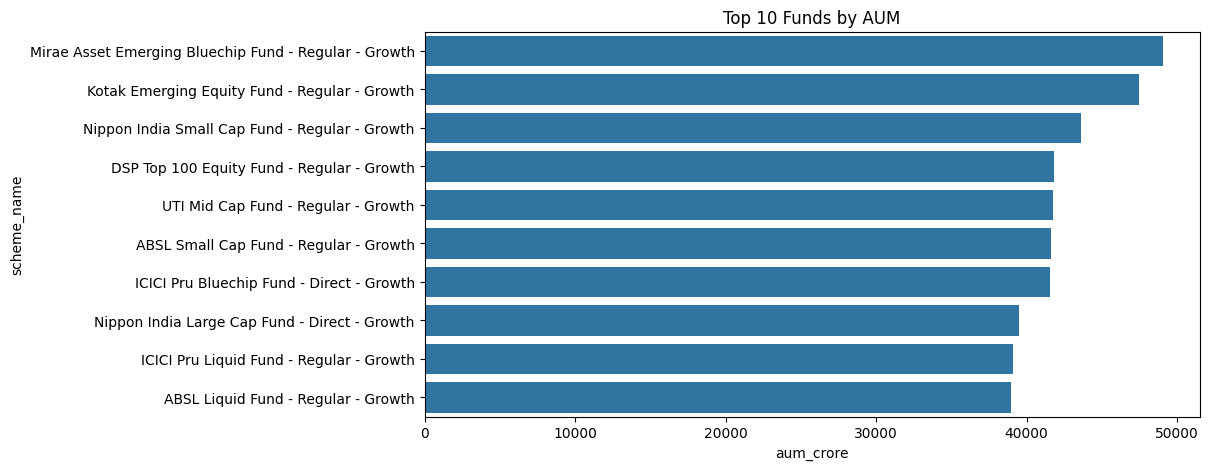

In [47]:
top10 = perf.nlargest(10,"aum_crore")

plt.figure(figsize=(10,5))

sns.barplot(
    data=top10,
    x="aum_crore",
    y="scheme_name"
)

plt.title("Top 10 Funds by AUM")

plt.savefig(wd/"top10_aum.png")

plt.show()

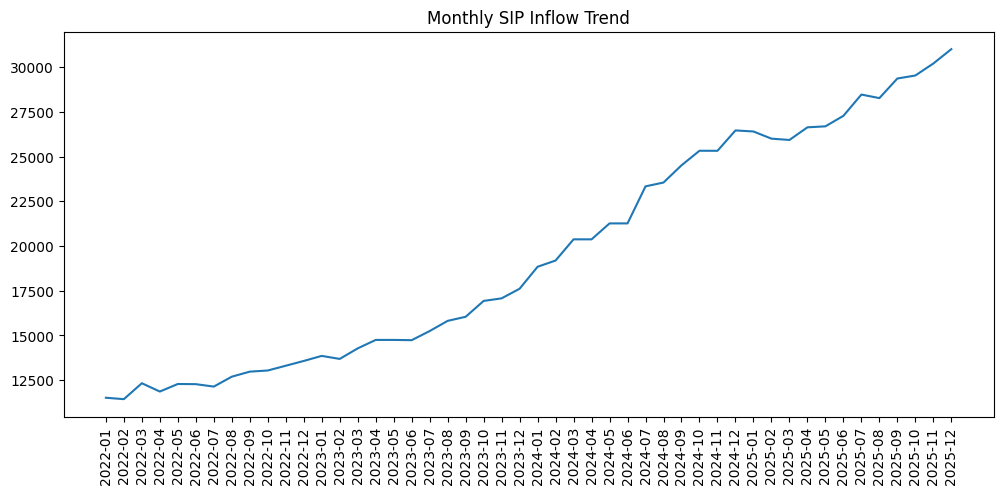

In [48]:
plt.figure(figsize=(12,5))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"]
)

plt.xticks(rotation=90)

plt.title("Monthly SIP Inflow Trend")

plt.savefig(wd/"sip_trend.png")

plt.show()

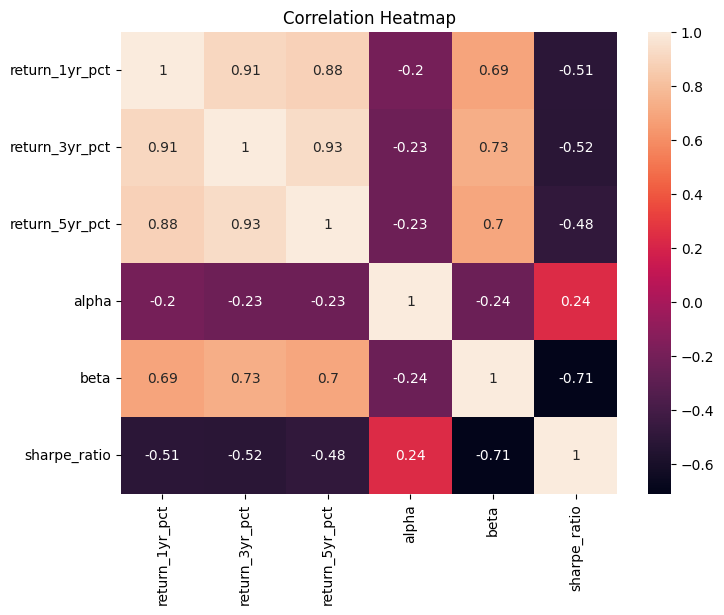

In [49]:
corr = perf[
[
"return_1yr_pct",
"return_3yr_pct",
"return_5yr_pct",
"alpha",
"beta",
"sharpe_ratio"
]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True
)

plt.title("Correlation Heatmap")

plt.savefig(wd/"correlation_heatmap.png")

plt.show()